CHECKING FILES IN /content
EURUSD_from_2018.csv: OK
GBPUSD_from_2018.csv: OK
USDJPY_from_2018.csv: OK
EURJPY_from_2018.csv: OK
USDCHF_from_2018.csv: OK
GBPJPY_from_2018.csv: OK
EURGBP_from_2018.csv: OK

RAW FILE DATE RANGES
EURUSD : 2018-01-01 00:00:00 -> 2026-02-16 00:00:00 | rows: 2121
GBPUSD : 2018-01-01 00:00:00 -> 2026-02-16 00:00:00 | rows: 2121
USDJPY : 2018-01-01 00:00:00 -> 2026-02-16 00:00:00 | rows: 2121
EURJPY : 2018-01-01 00:00:00 -> 2026-02-16 00:00:00 | rows: 2121
USDCHF : 2018-01-01 00:00:00 -> 2026-02-16 00:00:00 | rows: 2121
GBPJPY : 2023-02-05 00:00:00 -> 2026-02-16 00:00:00 | rows: 1000
EURGBP : 2018-01-01 00:00:00 -> 2026-02-16 00:00:00 | rows: 2121

PHASE 2 — DATA LOADING

Loaded FX pairs: ['EURUSD', 'GBPUSD', 'USDJPY', 'EURJPY', 'USDCHF', 'GBPJPY', 'EURGBP']
Global date range: 2018-01-01 00:00:00 -> 2026-02-16 00:00:00

Missing values per pair:
EURUSD     209
GBPUSD     209
USDJPY     209
EURJPY     209
USDCHF     209
GBPJPY    1330
EURGBP     209
dtype: int64

A

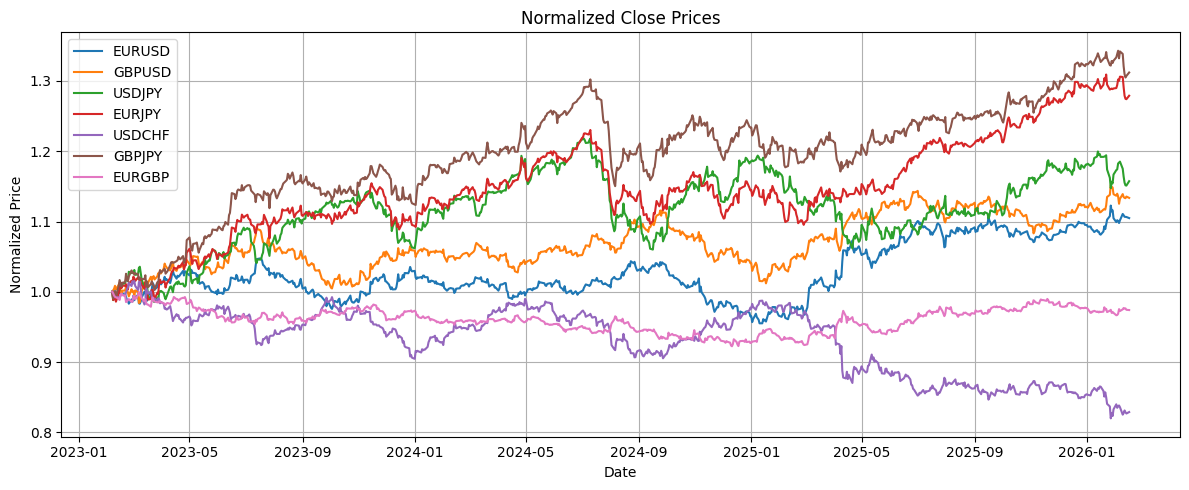

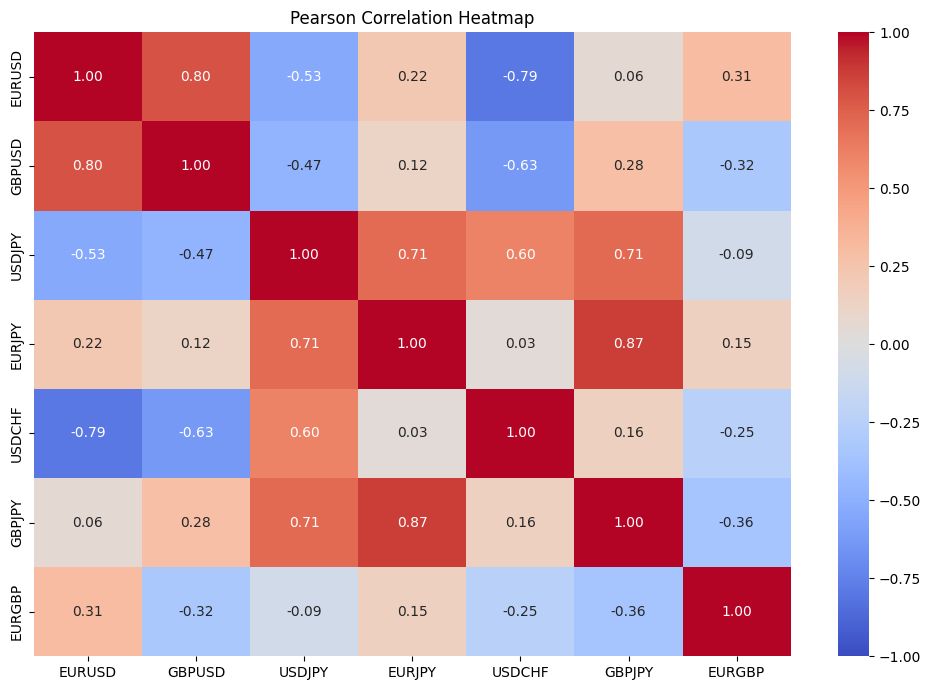

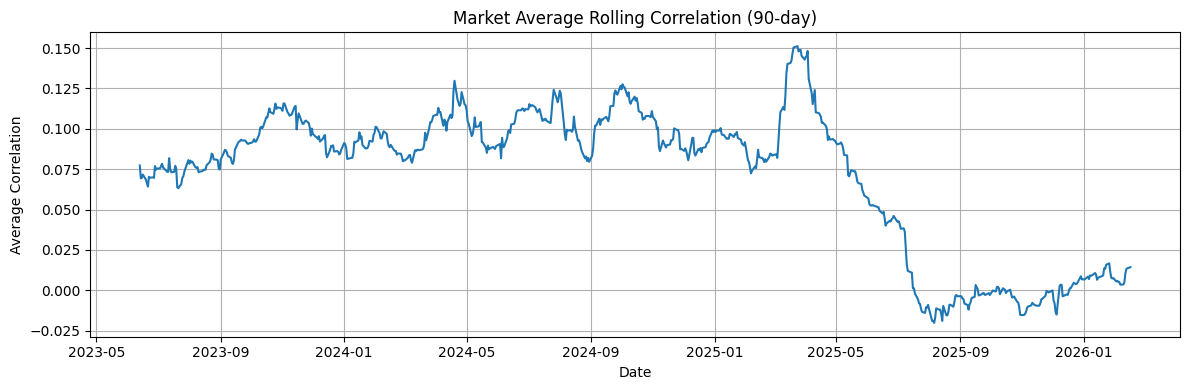


PHASE 3 — MODELING

--- Modeling for EURUSD ---
Top 3 correlated pairs: ['GBPUSD', 'EURGBP', 'EURJPY']
Train rows = 512 | Test rows = 129


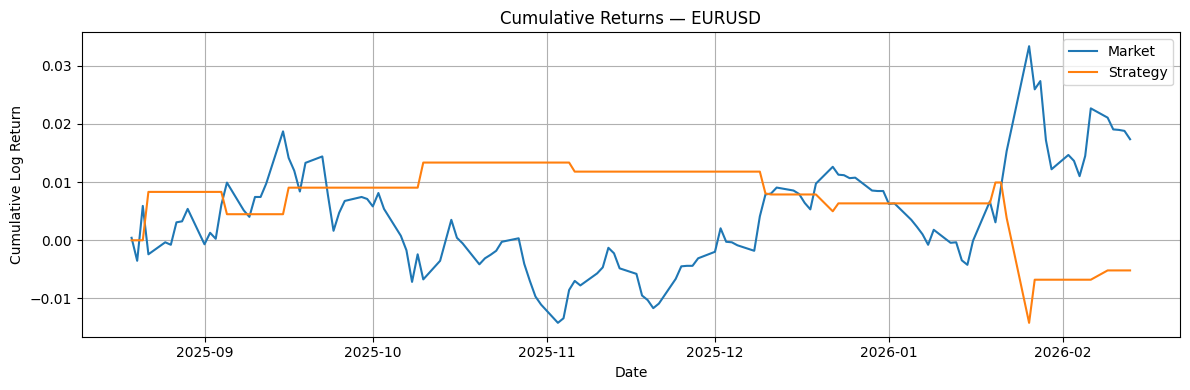

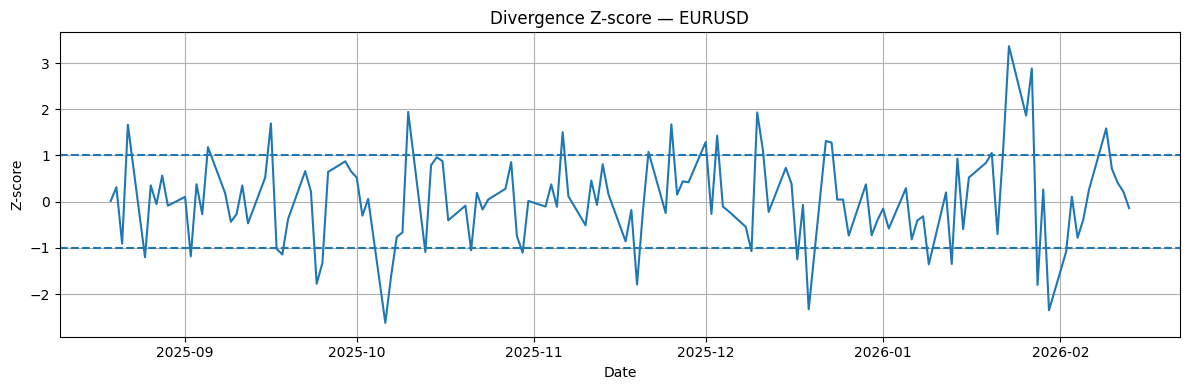

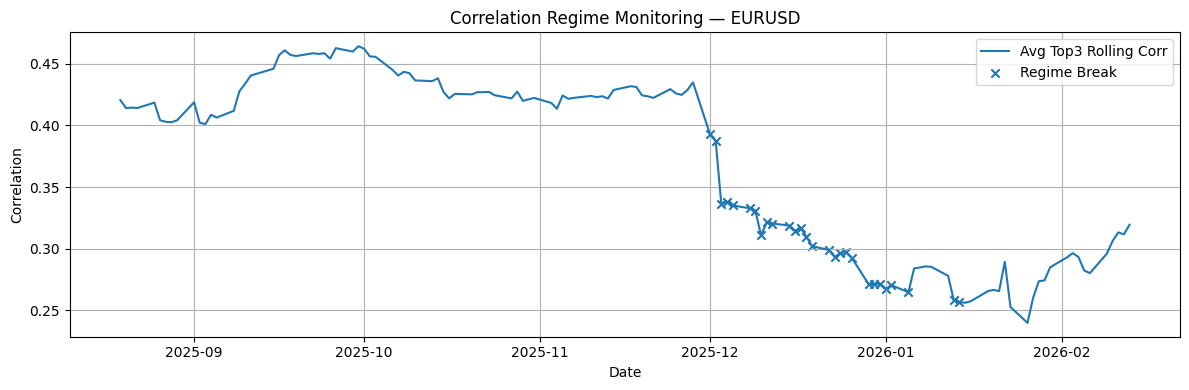


--- Modeling for GBPUSD ---
Top 3 correlated pairs: ['EURUSD', 'GBPJPY', 'EURJPY']
Train rows = 512 | Test rows = 129


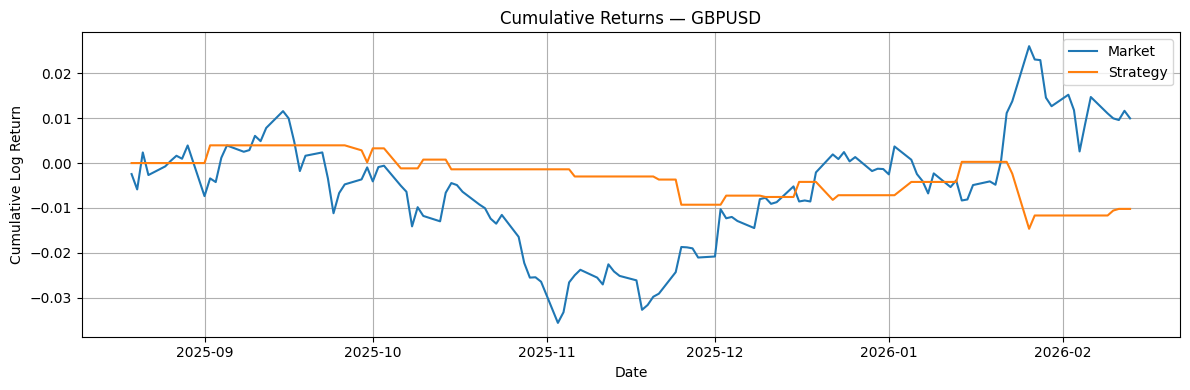

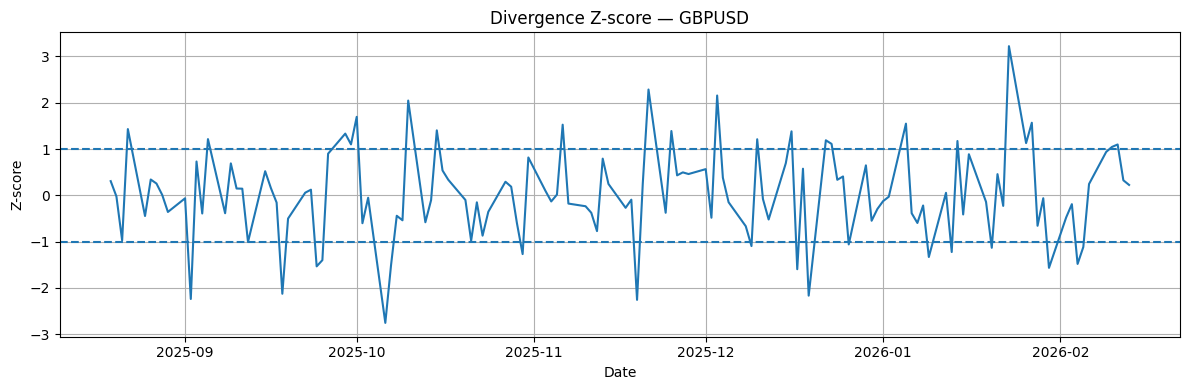

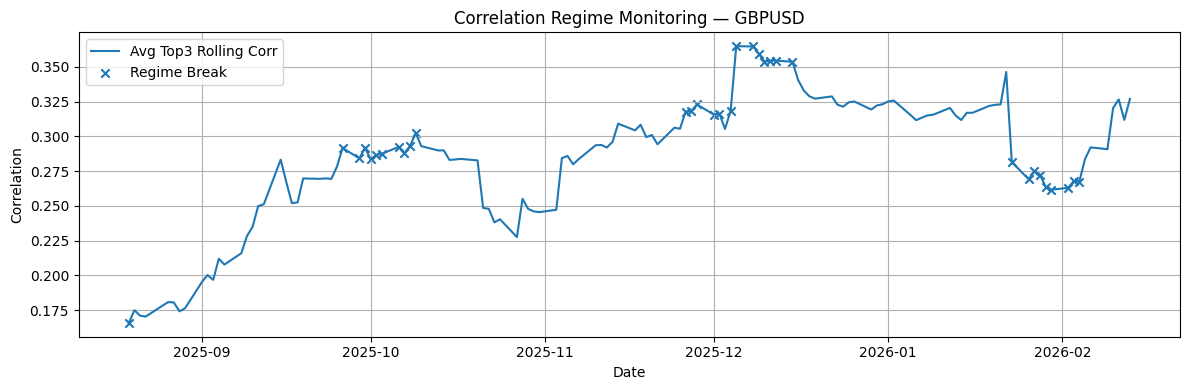


--- Modeling for USDJPY ---
Top 3 correlated pairs: ['GBPJPY', 'EURJPY', 'USDCHF']
Train rows = 512 | Test rows = 129


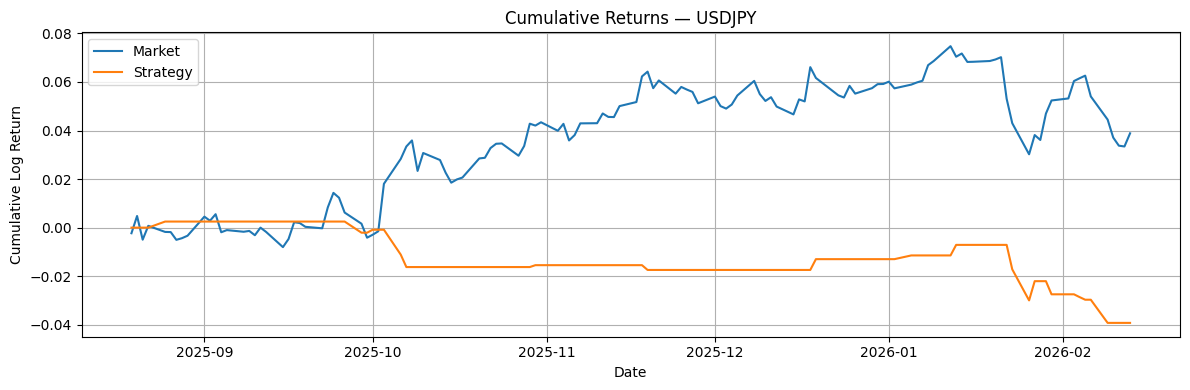

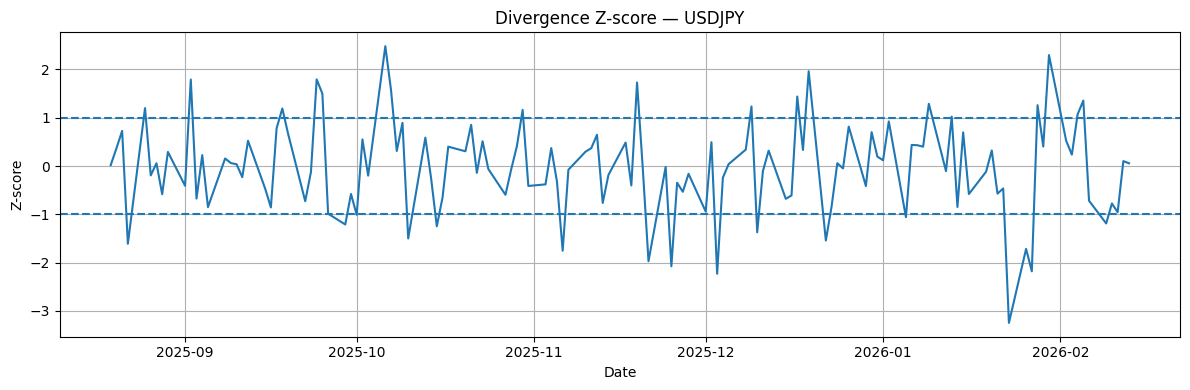

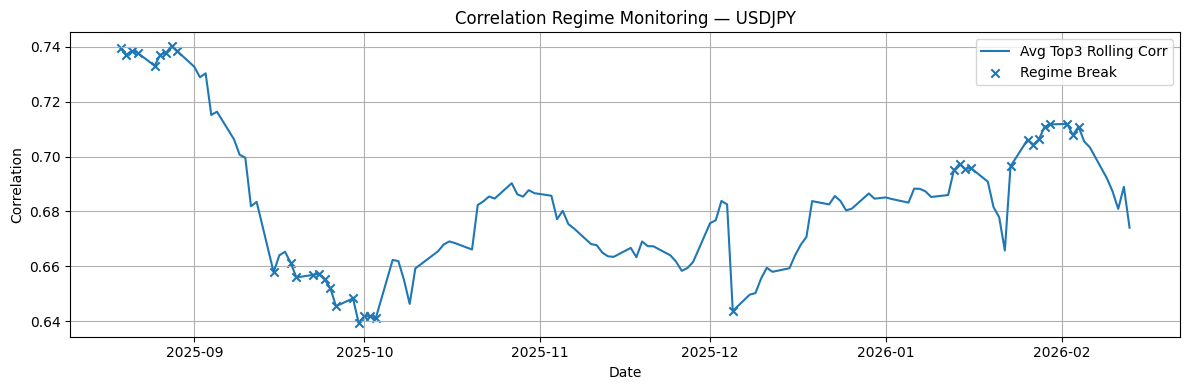


--- Modeling for EURJPY ---
Top 3 correlated pairs: ['GBPJPY', 'USDJPY', 'EURUSD']
Train rows = 512 | Test rows = 129


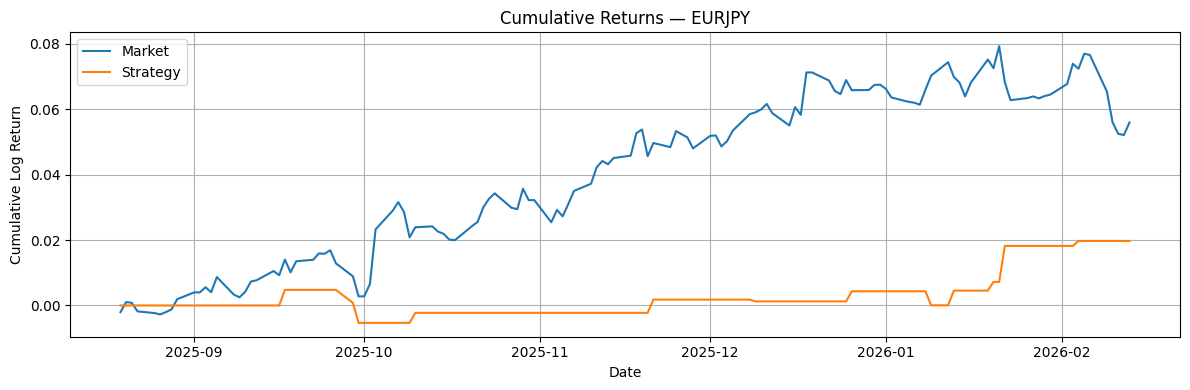

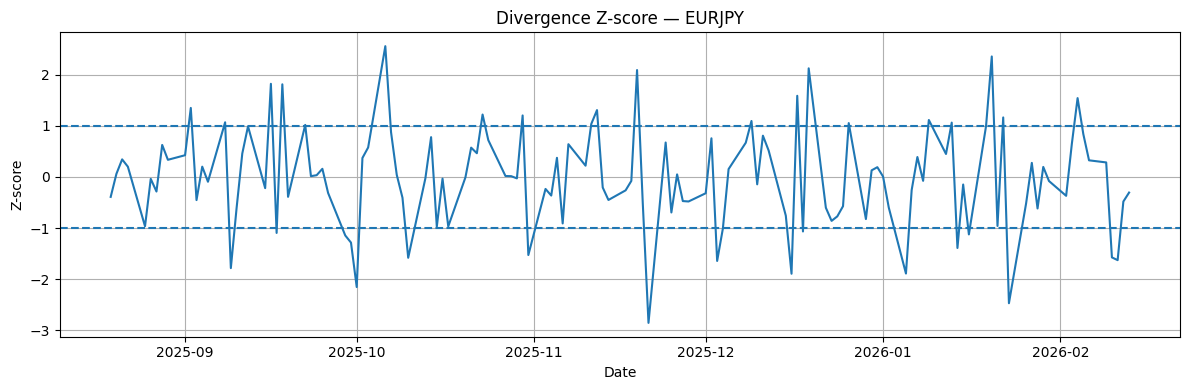

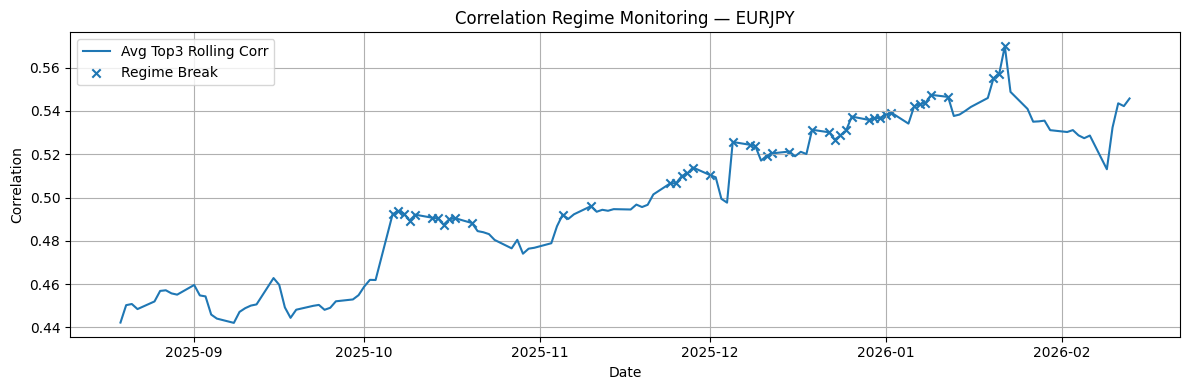


--- Modeling for USDCHF ---
Top 3 correlated pairs: ['USDJPY', 'GBPJPY', 'EURJPY']
Train rows = 512 | Test rows = 129


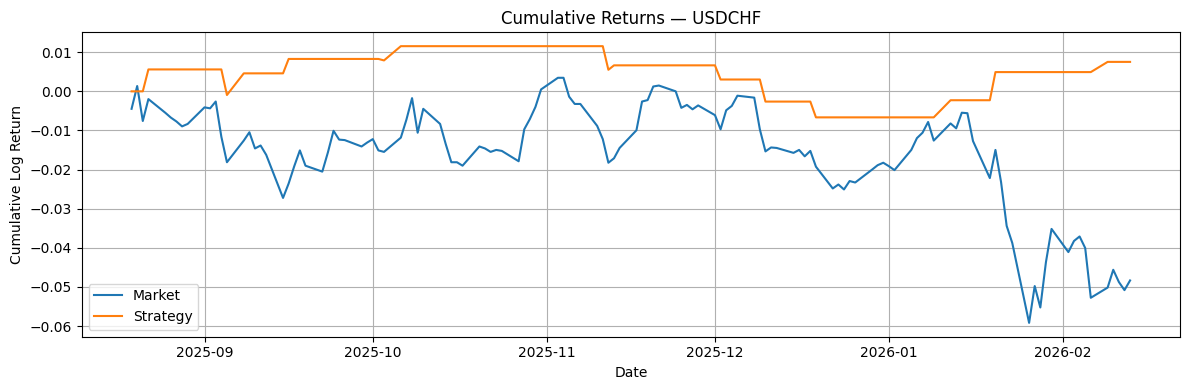

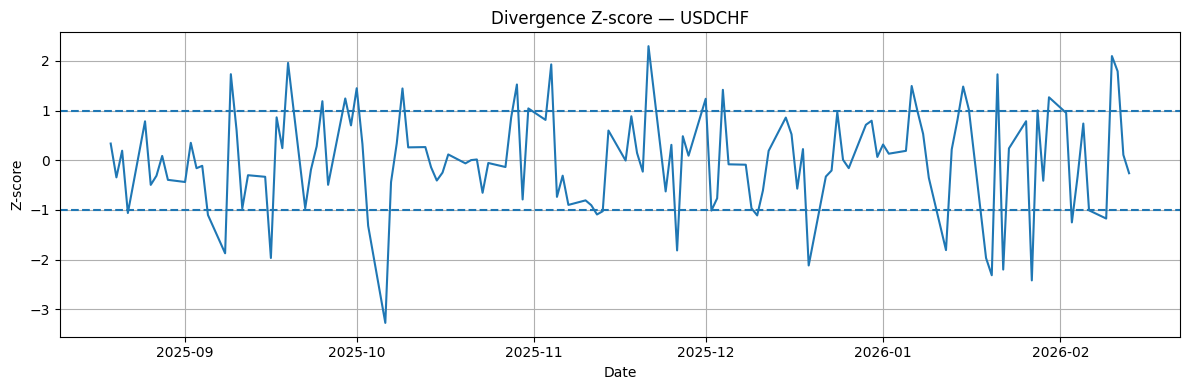

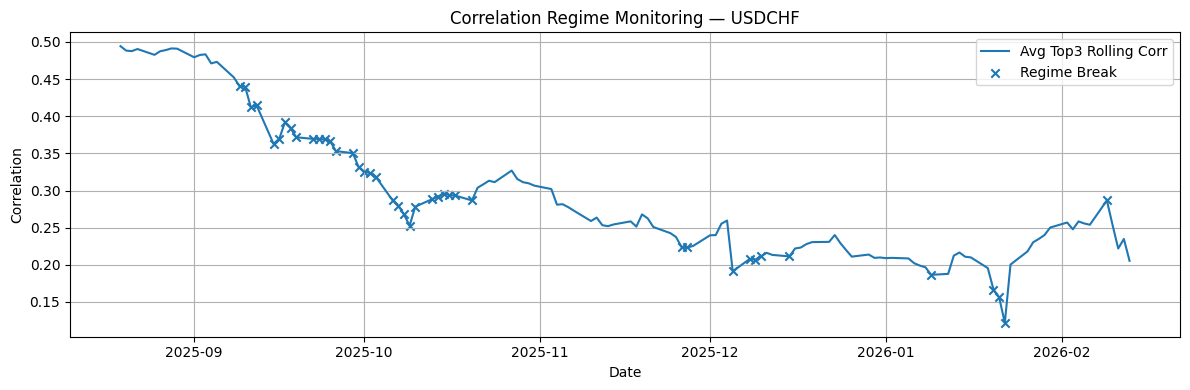


--- Modeling for GBPJPY ---
Top 3 correlated pairs: ['EURJPY', 'USDJPY', 'GBPUSD']
Train rows = 512 | Test rows = 129


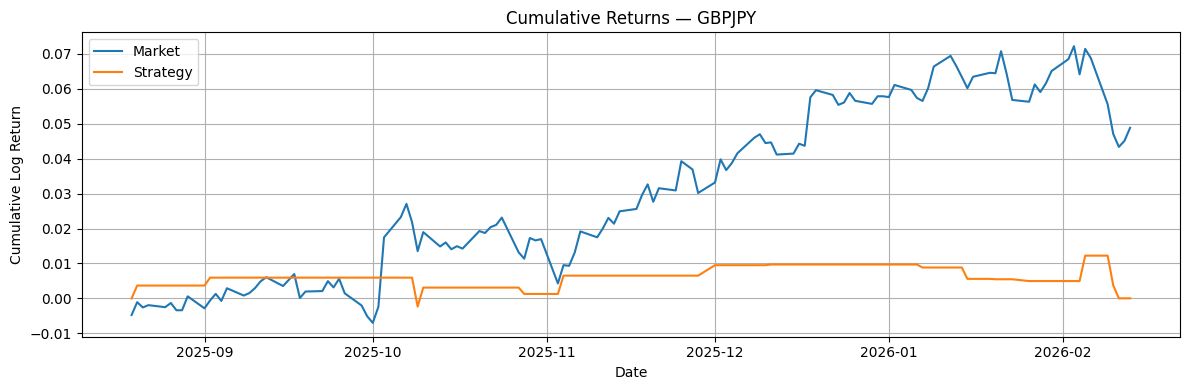

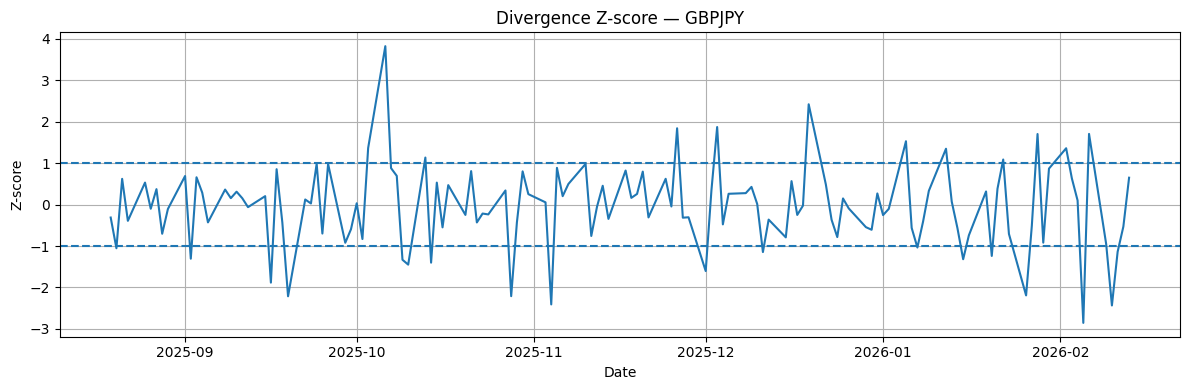

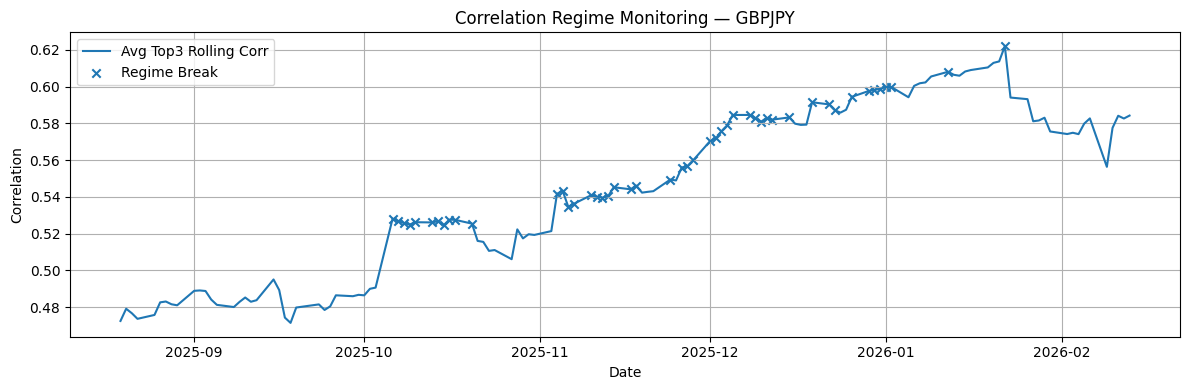


--- Modeling for EURGBP ---
Top 3 correlated pairs: ['EURUSD', 'EURJPY', 'USDJPY']
Train rows = 512 | Test rows = 129


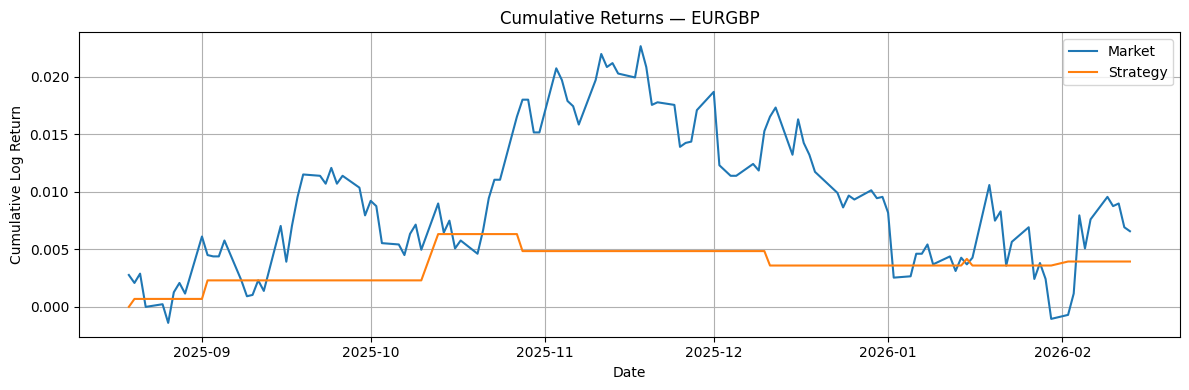

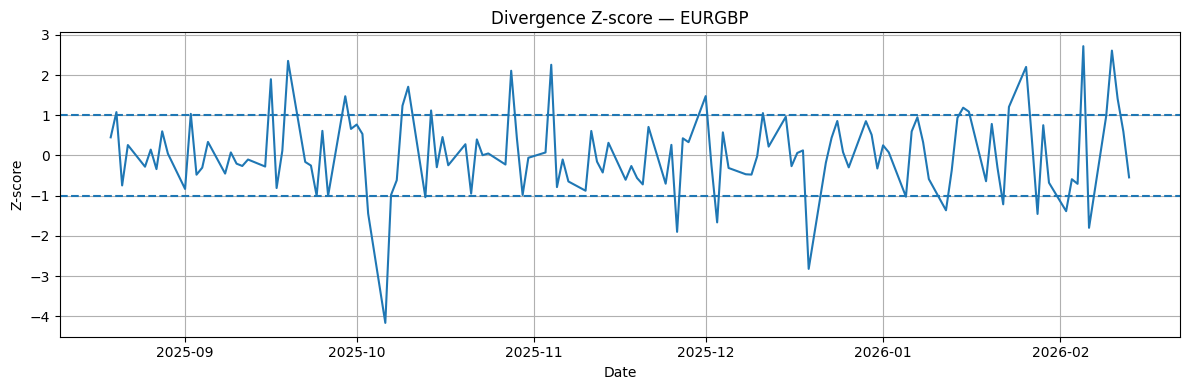

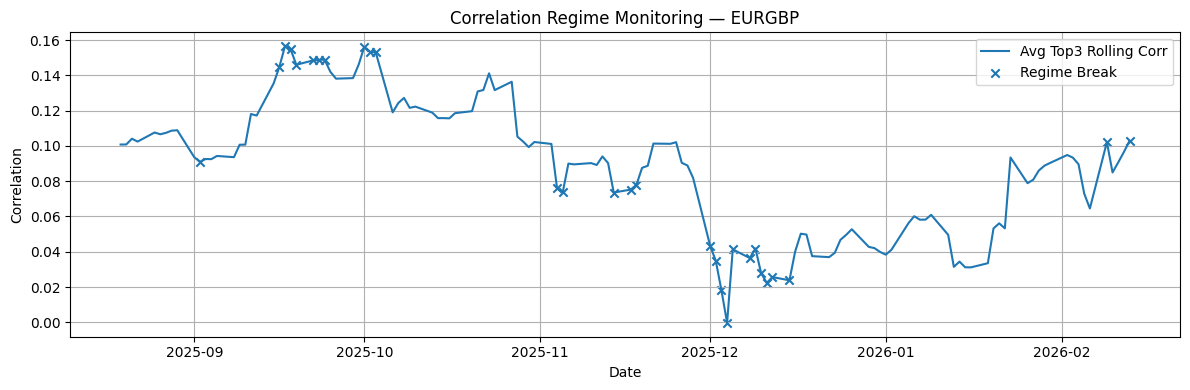


MODEL SUMMARY
  Pair              Top3Pairs  TrainRows  TestRows  Reg_MAE  Reg_RMSE    Reg_R2  Cls_Accuracy  Cls_Precision  Cls_Recall   Cls_F1  Trades_HitRatio  Strategy_CumRet  Market_CumRet  Strategy_Sharpe  Market_Sharpe  Strategy_MaxDD  Market_MaxDD  Num_BUY  Num_SELL  Num_HOLD
EURGBP EURUSD, EURJPY, USDJPY        512       129 0.001837  0.002388 -0.065534      0.604651       0.600000    0.491803 0.540541         0.625000         0.003946       0.006581         1.132434       0.350058       -0.002734     -0.023719        2         6       121
EURJPY GBPJPY, USDJPY, EURUSD        512       129 0.003204  0.004291 -0.134055      0.519380       0.578947    0.323529 0.415094         0.533333         0.019718       0.055966         1.652926       1.709032       -0.010096     -0.027168        6         9       114
EURUSD GBPUSD, EURGBP, EURJPY        512       129 0.004360  0.005521 -1.341779      0.596899       0.681818    0.250000 0.365854         0.466667        -0.005178       0.017

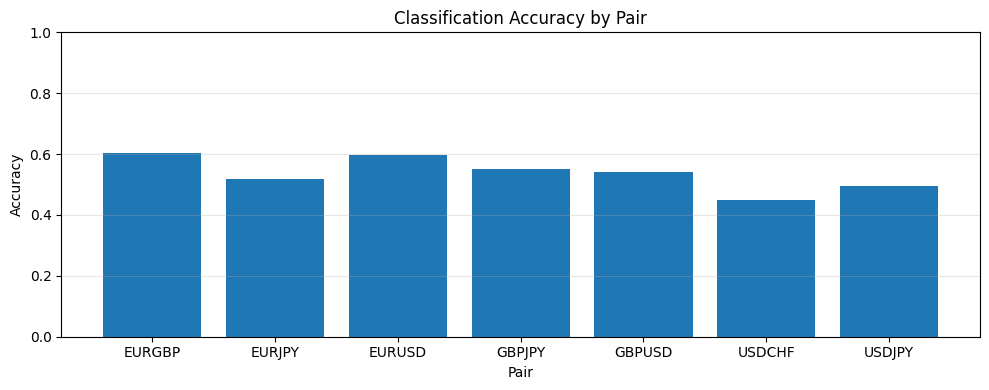

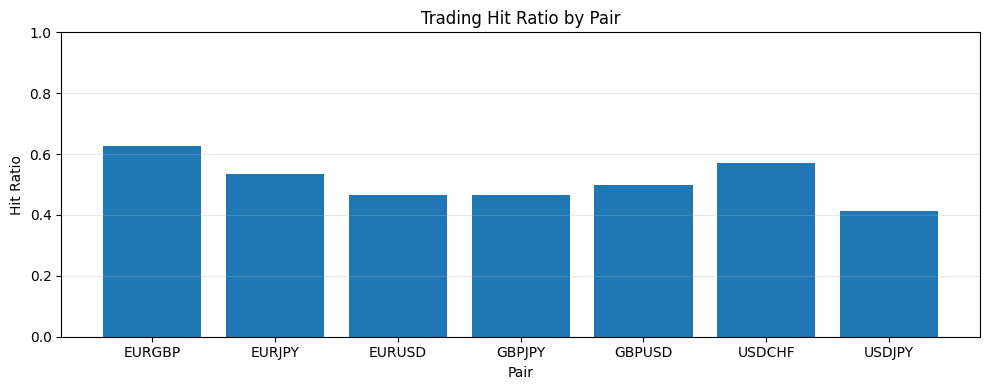

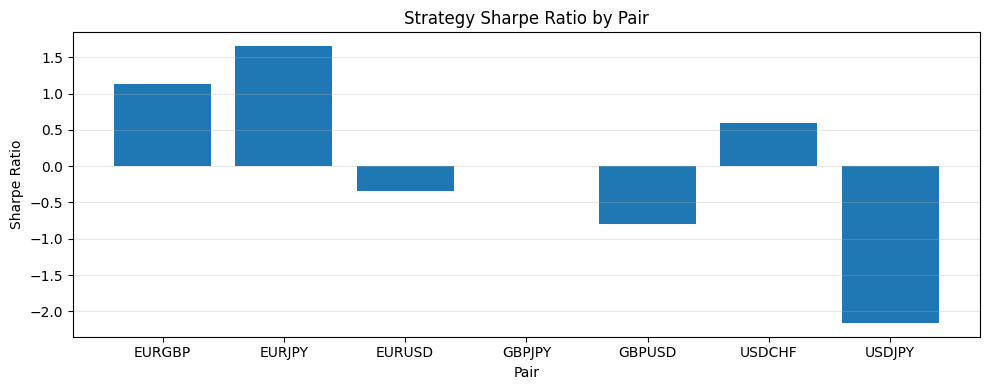

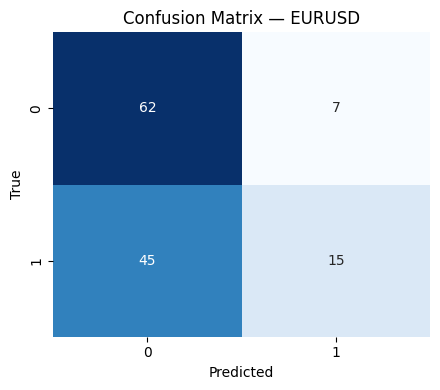

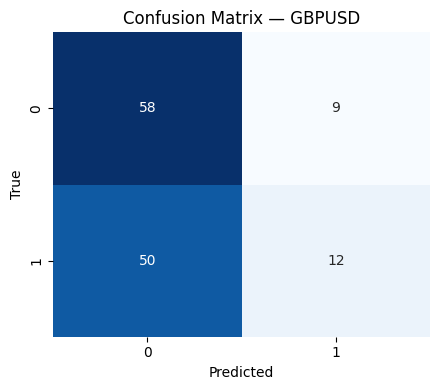

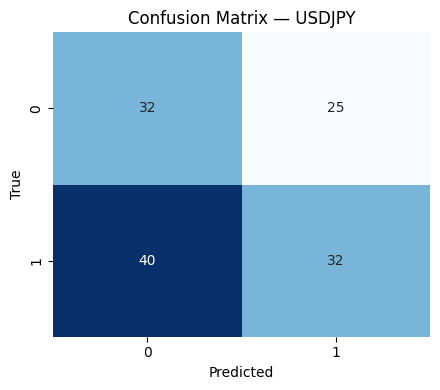

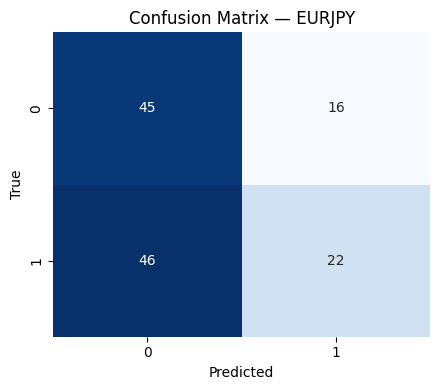

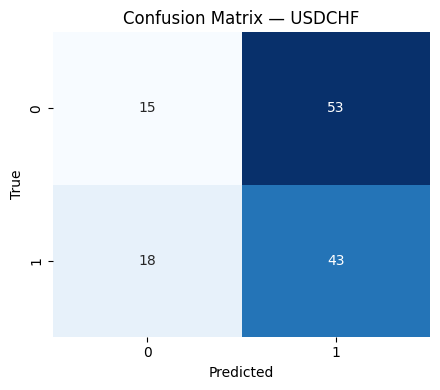

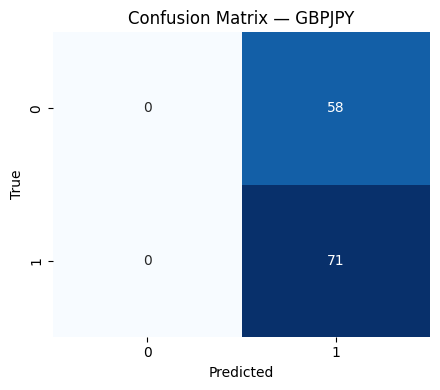

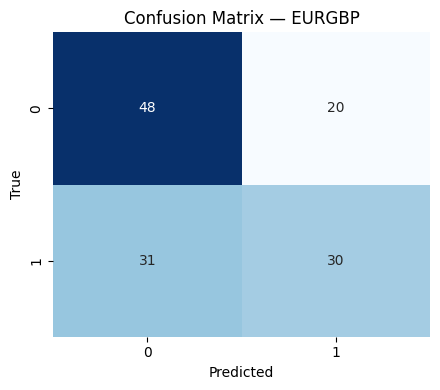


Phase 3 completed.
Outputs saved in: ./outputs_fx_alphalab_corr_agent


In [3]:
# ============================================================
# FX-AlphaLab — Correlation Agent
# Complete Modeling Notebook (Google Colab, corrected version)
# ============================================================

# =========================
# 1) IMPORTS
# =========================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

import joblib


# =========================
# 2) CONFIG
# =========================
DATA_DIR = "/content"
OUT_DIR = "./outputs_fx_alphalab_corr_agent"
os.makedirs(OUT_DIR, exist_ok=True)

PAIR_FILES = {
    "EURUSD": "EURUSD_from_2018.csv",
    "GBPUSD": "GBPUSD_from_2018.csv",
    "USDJPY": "USDJPY_from_2018.csv",
    "EURJPY": "EURJPY_from_2018.csv",
    "USDCHF": "USDCHF_from_2018.csv",
    "GBPJPY": "GBPJPY_from_2018.csv",
    "EURGBP": "EURGBP_from_2018.csv",
}

ROLL_WIN = 90
Z_TH = 4.0
BREAK_TH = 1.5
MIN_ROWS_TRAIN = 300
MIN_ROWS_TEST = 50

FEAT_WINS = [5, 10, 20, 50]

# Signal thresholds
PROBA_BUY = 0.55
PROBA_SELL = 0.45
MIN_EXPECTED_RET = 0.0003
DIVERGENCE_Z_BUY = -1.0
DIVERGENCE_Z_SELL = 1.0

np.random.seed(42)


# =========================
# 3) CHECK FILES
# =========================
print("=" * 80)
print("CHECKING FILES IN /content")
print("=" * 80)

for f in PAIR_FILES.values():
    path = os.path.join(DATA_DIR, f)
    print(f"{f}: {'OK' if os.path.exists(path) else 'NOT FOUND'}")


# =========================
# 4) HELPER FUNCTIONS
# =========================
def rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    up = delta.clip(lower=0)
    down = (-delta).clip(lower=0)
    roll_up = up.rolling(window).mean()
    roll_down = down.rolling(window).mean()
    rs = roll_up / (roll_down + 1e-12)
    return 100 - (100 / (1 + rs))


def adf_test(series, name="series"):
    series = series.dropna()
    stat, pvalue, *_ = adfuller(series, autolag="AIC")
    return {
        "name": name,
        "adf_stat": stat,
        "p_value": pvalue,
        "stationary_5pct": pvalue < 0.05
    }


def regression_metrics(y_true, y_pred) -> dict:
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }


def classification_metrics(y_true, y_pred) -> dict:
    return {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
    }


def sharpe_ratio(returns, annualization=252):
    returns = pd.Series(returns).dropna()
    if returns.std(ddof=0) < 1e-12:
        return 0.0
    return np.sqrt(annualization) * returns.mean() / returns.std(ddof=0)


def max_drawdown(cum_returns):
    cum_returns = pd.Series(cum_returns).dropna()
    running_max = cum_returns.cummax()
    drawdown = cum_returns - running_max
    return float(drawdown.min())


def time_split(df: pd.DataFrame, split_date: str = None, train_ratio: float = 0.8):
    if split_date is not None:
        train = df[df.index < split_date].copy()
        test = df[df.index >= split_date].copy()
    else:
        split_idx = int(len(df) * train_ratio)
        train = df.iloc[:split_idx].copy()
        test = df.iloc[split_idx:].copy()
    return train, test


def compute_top3_pairs_from_train(pair: str, returns_train: pd.DataFrame):
    corr_train = returns_train.corr()
    top3 = corr_train[pair].drop(index=[pair]).sort_values(ascending=False).head(3).index.tolist()
    return top3


def compute_market_average_correlation(returns_df: pd.DataFrame, roll_win: int):
    dates = returns_df.index
    out = pd.Series(index=dates, dtype=float)

    for i in range(roll_win, len(dates)):
        window = returns_df.iloc[i-roll_win:i]
        corr = window.corr().values
        n = corr.shape[0]
        if n <= 1:
            out.iloc[i] = np.nan
            continue
        mask = ~np.eye(n, dtype=bool)
        out.iloc[i] = corr[mask].mean()

    return out


def compute_pairwise_rolling_features(target_pair: str, top3_pairs: list, returns_df: pd.DataFrame, roll_win: int):
    feat = pd.DataFrame(index=returns_df.index)

    pair_corr_cols = []
    for other in top3_pairs:
        col_name = f"roll_corr_{target_pair}_{other}"
        feat[col_name] = returns_df[target_pair].rolling(roll_win).corr(returns_df[other])
        pair_corr_cols.append(col_name)

    feat["avg_top3_roll_corr"] = feat[pair_corr_cols].mean(axis=1)
    feat["std_top3_roll_corr"] = feat[pair_corr_cols].std(axis=1)
    feat["corr_stability_score"] = feat["avg_top3_roll_corr"] / (feat["std_top3_roll_corr"] + 1e-6)

    roll_mean = feat["avg_top3_roll_corr"].rolling(60).mean()
    roll_std = feat["avg_top3_roll_corr"].rolling(60).std()
    feat["avg_top3_roll_corr_z"] = (feat["avg_top3_roll_corr"] - roll_mean) / (roll_std + 1e-6)
    feat["corr_break_flag"] = (feat["avg_top3_roll_corr_z"].abs() > BREAK_TH).astype(int)

    return feat


def build_features_for_pair(pair: str,
                            closes_df: pd.DataFrame,
                            returns_df: pd.DataFrame,
                            top3_pairs: list,
                            market_avg_corr: pd.Series) -> pd.DataFrame:
    px = closes_df[pair]
    r = returns_df[pair]

    feat = pd.DataFrame(index=returns_df.index)

    # Short memory
    for lag in [1, 2, 3, 5, 10]:
        feat[f"ret_lag_{lag}"] = r.shift(lag)

    for w in FEAT_WINS:
        feat[f"ret_mean_{w}"] = r.rolling(w).mean()
        feat[f"ret_std_{w}"] = r.rolling(w).std()

    # Light technical context
    for w in [10, 20, 50]:
        ma = px.rolling(w).mean()
        feat[f"ma_ratio_{w}"] = (px / (ma + 1e-12)) - 1.0

    feat["rsi_14"] = rsi(px, 14)

    # Market-wide correlation regime
    feat["market_avg_corr"] = market_avg_corr
    feat["market_avg_corr_change_5"] = market_avg_corr.diff(5)

    # Rolling correlation with top3
    corr_feat = compute_pairwise_rolling_features(pair, top3_pairs, returns_df, ROLL_WIN)
    feat = feat.join(corr_feat)

    # Divergence features
    top3_mean_ret = returns_df[top3_pairs].mean(axis=1)
    spread = returns_df[pair] - top3_mean_ret

    feat["spread_vs_top3"] = spread
    feat["spread_mean_30"] = spread.rolling(30).mean()
    feat["spread_std_30"] = spread.rolling(30).std()
    feat["divergence_zscore"] = (
        (spread - feat["spread_mean_30"]) / (feat["spread_std_30"] + 1e-6)
    )

    # Other pairs lagged returns
    for other in returns_df.columns:
        if other != pair:
            feat[f"other_ret_{other}_lag1"] = returns_df[other].shift(1)

    # Correlation Agent score
    feat["correlation_score"] = (
        feat["avg_top3_roll_corr"] * 0.5
        + np.tanh(feat["corr_stability_score"]) * 0.3
        - feat["corr_break_flag"] * 0.2
    )

    return feat


def make_targets(pair: str, returns_df: pd.DataFrame):
    y_reg = returns_df[pair].shift(-1)
    y_cls = (returns_df[pair].shift(-1) > 0).astype(int)
    return y_reg, y_cls


def build_signals(proba_up: np.ndarray,
                  expected_ret: np.ndarray,
                  divergence_z: np.ndarray,
                  corr_score: np.ndarray) -> np.ndarray:
    buy_cond = (
        (proba_up >= PROBA_BUY)
        & (expected_ret >= MIN_EXPECTED_RET)
        & (divergence_z <= DIVERGENCE_Z_BUY)
        & (corr_score > -0.5)
    )

    sell_cond = (
        (proba_up <= PROBA_SELL)
        & (expected_ret <= -MIN_EXPECTED_RET)
        & (divergence_z >= DIVERGENCE_Z_SELL)
        & (corr_score > -0.5)
    )

    return np.where(buy_cond, "BUY", np.where(sell_cond, "SELL", "HOLD"))


def backtest_signals(signal_series: pd.Series, realized_next_ret: pd.Series) -> pd.DataFrame:
    signal_num = signal_series.map({"BUY": 1, "SELL": -1, "HOLD": 0}).fillna(0)
    strat_ret = signal_num * realized_next_ret
    out = pd.DataFrame({
        "signal": signal_series,
        "signal_num": signal_num,
        "realized_next_ret": realized_next_ret,
        "strategy_ret": strat_ret
    })
    out["cum_market"] = realized_next_ret.cumsum()
    out["cum_strategy"] = out["strategy_ret"].cumsum()
    return out


# =========================
# 5) LOAD RAW DATA + RANGE CHECK
# =========================
print("\n" + "=" * 80)
print("RAW FILE DATE RANGES")
print("=" * 80)

for pair, fname in PAIR_FILES.items():
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.exists(fpath):
        tmp = pd.read_csv(fpath, parse_dates=[0], index_col=0).sort_index()
        print(pair, ":", tmp.index.min(), "->", tmp.index.max(), "| rows:", len(tmp))


# =========================
# 6) LOAD DATA
# =========================
print("\n" + "=" * 80)
print("PHASE 2 — DATA LOADING")
print("=" * 80)

prices = {}
for pair, fname in PAIR_FILES.items():
    fpath = os.path.join(DATA_DIR, fname)

    if not os.path.exists(fpath):
        raise FileNotFoundError(f"File not found: {fpath}")

    df = pd.read_csv(fpath, parse_dates=[0], index_col=0).sort_index()

    if "Close" not in df.columns:
        raise ValueError(f"'Close' column not found in {fname}")

    prices[pair] = df["Close"].astype(float)

closes = pd.DataFrame(prices).sort_index()

print("\nLoaded FX pairs:", list(closes.columns))
print("Global date range:", closes.index.min(), "->", closes.index.max())

print("\nMissing values per pair:")
print(closes.isna().sum())

closes_aligned = closes.dropna().copy()
returns = np.log(closes_aligned / closes_aligned.shift(1)).dropna()

closes_aligned.to_csv(os.path.join(OUT_DIR, "closes_aligned.csv"))
returns.to_csv(os.path.join(OUT_DIR, "log_returns.csv"))

print("\nAligned data shape:", closes_aligned.shape)
print("Returns shape:", returns.shape)
print("\nReturns date range:")
print("Start:", returns.index.min())
print("End  :", returns.index.max())


# =========================
# 7) DATA UNDERSTANDING
# =========================
print("\n" + "=" * 80)
print("PHASE 2 — DATA UNDERSTANDING")
print("=" * 80)

outlier_report = []
for pair in returns.columns:
    z = (returns[pair] - returns[pair].mean()) / (returns[pair].std(ddof=0) + 1e-12)
    n_out = int((z.abs() > Z_TH).sum())
    outlier_report.append([pair, n_out])

outlier_df = pd.DataFrame(outlier_report, columns=["Pair", "NumOutliers"])
outlier_df.to_csv(os.path.join(OUT_DIR, "outlier_report.csv"), index=False)
print(outlier_df)

corr_pearson = returns.corr(method="pearson")
corr_spearman = returns.corr(method="spearman")

corr_pearson.to_csv(os.path.join(OUT_DIR, "corr_matrix_pearson.csv"))
corr_spearman.to_csv(os.path.join(OUT_DIR, "corr_matrix_spearman.csv"))

print("\nPearson Correlation Matrix:")
print(corr_pearson.round(3))

adf_results = [adf_test(returns[col], col) for col in returns.columns]
adf_df = pd.DataFrame(adf_results).sort_values("p_value")
adf_df.to_csv(os.path.join(OUT_DIR, "adf_stationarity_returns.csv"), index=False)

print("\nADF Results:")
print(adf_df)

market_avg_corr = compute_market_average_correlation(returns, ROLL_WIN)
market_avg_corr.to_csv(os.path.join(OUT_DIR, "market_avg_corr.csv"))


# =========================
# 8) VISUALIZATIONS
# =========================
plt.figure(figsize=(12, 5))
norm_prices = closes_aligned / closes_aligned.iloc[0]
for pair in norm_prices.columns:
    plt.plot(norm_prices.index, norm_prices[pair], label=pair)
plt.title("Normalized Close Prices")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "normalized_close_prices.png"))
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "corr_heatmap_pearson.png"))
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(market_avg_corr.index, market_avg_corr.values)
plt.title(f"Market Average Rolling Correlation ({ROLL_WIN}-day)")
plt.xlabel("Date")
plt.ylabel("Average Correlation")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "market_avg_rolling_corr.png"))
plt.show()


# =========================
# 9) MODELING
# =========================
print("\n" + "=" * 80)
print("PHASE 3 — MODELING")
print("=" * 80)

summary_results = []
feature_importance_rows = []
conf_mats = {}

for pair in closes_aligned.columns:
    print(f"\n--- Modeling for {pair} ---")

    # Build a temporary base to create split first
    y_reg_tmp = returns[pair].shift(-1)
    tmp_base = pd.DataFrame({"y_reg": y_reg_tmp}).dropna()
    train_base, test_base = time_split(tmp_base, split_date=None, train_ratio=0.8)

    if len(train_base) < MIN_ROWS_TRAIN or len(test_base) < MIN_ROWS_TEST:
        print(f"Not enough base rows for {pair}. Train={len(train_base)}, Test={len(test_base)}")
        continue

    returns_train_global = returns.loc[train_base.index].copy()

    top3_pairs = compute_top3_pairs_from_train(pair, returns_train_global)
    print("Top 3 correlated pairs:", top3_pairs)

    X = build_features_for_pair(
        pair=pair,
        closes_df=closes_aligned,
        returns_df=returns,
        top3_pairs=top3_pairs,
        market_avg_corr=market_avg_corr
    )

    y_reg, y_cls = make_targets(pair, returns)

    data = X.copy()
    data["y_reg"] = y_reg
    data["y_cls"] = y_cls
    data = data.dropna()

    train, test = time_split(data, split_date=None, train_ratio=0.8)

    print(f"Train rows = {len(train)} | Test rows = {len(test)}")

    if len(train) < MIN_ROWS_TRAIN or len(test) < MIN_ROWS_TEST:
        print(f"Not enough data for {pair}. Train={len(train)}, Test={len(test)}")
        continue

    X_train = train.drop(columns=["y_reg", "y_cls"])
    X_test = test.drop(columns=["y_reg", "y_cls"])

    yreg_train = train["y_reg"]
    yreg_test = test["y_reg"]

    ycls_train = train["y_cls"]
    ycls_test = test["y_cls"]

    # Regression
    reg_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])
    reg_model.fit(X_train, yreg_train)
    yreg_pred = reg_model.predict(X_test)
    reg_m = regression_metrics(yreg_test, yreg_pred)

    # Classification
    cls_model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=3000))
    ])
    cls_model.fit(X_train, ycls_train)
    ycls_pred = cls_model.predict(X_test)
    proba_up = cls_model.predict_proba(X_test)[:, 1]
    cls_m = classification_metrics(ycls_test, ycls_pred)

    cm = confusion_matrix(ycls_test, ycls_pred)
    conf_mats[pair] = cm

    # Feature importance
    coef = cls_model.named_steps["logreg"].coef_[0]
    feat_names = X_train.columns.tolist()
    coef_df = pd.DataFrame({
        "Pair": pair,
        "Feature": feat_names,
        "Coefficient": coef,
        "AbsCoefficient": np.abs(coef)
    }).sort_values("AbsCoefficient", ascending=False)

    coef_df.to_csv(os.path.join(OUT_DIR, f"{pair}_feature_importance.csv"), index=False)
    feature_importance_rows.append(coef_df.head(10))

    # Predictions
    pred_df = pd.DataFrame(index=X_test.index)
    pred_df["expected_next_ret"] = yreg_pred
    pred_df["proba_up"] = proba_up
    pred_df["y_cls_true"] = ycls_test.values
    pred_df["y_cls_pred"] = ycls_pred
    pred_df["realized_next_ret"] = yreg_test.values
    pred_df["divergence_zscore"] = X_test["divergence_zscore"].values
    pred_df["correlation_score"] = X_test["correlation_score"].values
    pred_df["corr_break_flag"] = X_test["corr_break_flag"].values
    pred_df["avg_top3_roll_corr"] = X_test["avg_top3_roll_corr"].values

    pred_df["signal"] = build_signals(
        proba_up=pred_df["proba_up"].values,
        expected_ret=pred_df["expected_next_ret"].values,
        divergence_z=pred_df["divergence_zscore"].values,
        corr_score=pred_df["correlation_score"].values
    )

    # Backtest
    bt = backtest_signals(pred_df["signal"], pred_df["realized_next_ret"])
    pred_df = pred_df.join(bt[["signal_num", "strategy_ret", "cum_market", "cum_strategy"]])

    hit_ratio = (
        ((pred_df["signal"] == "BUY") & (pred_df["realized_next_ret"] > 0)) |
        ((pred_df["signal"] == "SELL") & (pred_df["realized_next_ret"] < 0))
    )
    non_hold_mask = pred_df["signal"] != "HOLD"
    hit_ratio_value = float(hit_ratio[non_hold_mask].mean()) if non_hold_mask.sum() > 0 else 0.0

    strat_sharpe = sharpe_ratio(pred_df["strategy_ret"])
    market_sharpe = sharpe_ratio(pred_df["realized_next_ret"])

    strat_cumret = float(pred_df["strategy_ret"].sum())
    market_cumret = float(pred_df["realized_next_ret"].sum())

    strat_mdd = max_drawdown(pred_df["cum_strategy"])
    market_mdd = max_drawdown(pred_df["cum_market"])

    n_buy = int((pred_df["signal"] == "BUY").sum())
    n_sell = int((pred_df["signal"] == "SELL").sum())
    n_hold = int((pred_df["signal"] == "HOLD").sum())

    pred_df.to_csv(os.path.join(OUT_DIR, f"{pair}_predictions_signals_backtest.csv"))
    joblib.dump(reg_model, os.path.join(OUT_DIR, f"{pair}_reg_model.pkl"))
    joblib.dump(cls_model, os.path.join(OUT_DIR, f"{pair}_cls_model.pkl"))

    summary_results.append({
        "Pair": pair,
        "Top3Pairs": ", ".join(top3_pairs),
        "TrainRows": int(len(train)),
        "TestRows": int(len(test)),
        "Reg_MAE": reg_m["MAE"],
        "Reg_RMSE": reg_m["RMSE"],
        "Reg_R2": reg_m["R2"],
        "Cls_Accuracy": cls_m["Accuracy"],
        "Cls_Precision": cls_m["Precision"],
        "Cls_Recall": cls_m["Recall"],
        "Cls_F1": cls_m["F1"],
        "Trades_HitRatio": hit_ratio_value,
        "Strategy_CumRet": strat_cumret,
        "Market_CumRet": market_cumret,
        "Strategy_Sharpe": strat_sharpe,
        "Market_Sharpe": market_sharpe,
        "Strategy_MaxDD": strat_mdd,
        "Market_MaxDD": market_mdd,
        "Num_BUY": n_buy,
        "Num_SELL": n_sell,
        "Num_HOLD": n_hold
    })

    # Plots per pair
    plt.figure(figsize=(12, 4))
    plt.plot(pred_df.index, pred_df["cum_market"], label="Market")
    plt.plot(pred_df.index, pred_df["cum_strategy"], label="Strategy")
    plt.title(f"Cumulative Returns — {pair}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Log Return")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{pair}_cum_returns.png"))
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(pred_df.index, pred_df["divergence_zscore"])
    plt.axhline(1.0, linestyle="--")
    plt.axhline(-1.0, linestyle="--")
    plt.title(f"Divergence Z-score — {pair}")
    plt.xlabel("Date")
    plt.ylabel("Z-score")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{pair}_divergence_zscore.png"))
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(pred_df.index, pred_df["avg_top3_roll_corr"], label="Avg Top3 Rolling Corr")
    plt.scatter(
        pred_df.index[pred_df["corr_break_flag"] == 1],
        pred_df.loc[pred_df["corr_break_flag"] == 1, "avg_top3_roll_corr"],
        label="Regime Break",
        marker="x"
    )
    plt.title(f"Correlation Regime Monitoring — {pair}")
    plt.xlabel("Date")
    plt.ylabel("Correlation")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{pair}_correlation_regime.png"))
    plt.show()


# =========================
# 10) GLOBAL RESULTS
# =========================
summary_df = pd.DataFrame(summary_results)

if not summary_df.empty:
    summary_df = summary_df.sort_values("Pair")
    summary_df.to_csv(os.path.join(OUT_DIR, "modeling_summary_metrics.csv"), index=False)

    print("\n" + "=" * 80)
    print("MODEL SUMMARY")
    print("=" * 80)
    print(summary_df.to_string(index=False))

    if len(feature_importance_rows) > 0:
        top_feat_df = pd.concat(feature_importance_rows, axis=0)
        top_feat_df.to_csv(os.path.join(OUT_DIR, "top_feature_importances_all_pairs.csv"), index=False)

    plt.figure(figsize=(10, 4))
    plt.bar(summary_df["Pair"], summary_df["Cls_Accuracy"])
    plt.title("Classification Accuracy by Pair")
    plt.xlabel("Pair")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "accuracy_by_pair.png"))
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.bar(summary_df["Pair"], summary_df["Trades_HitRatio"])
    plt.title("Trading Hit Ratio by Pair")
    plt.xlabel("Pair")
    plt.ylabel("Hit Ratio")
    plt.ylim(0, 1)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "hit_ratio_by_pair.png"))
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.bar(summary_df["Pair"], summary_df["Strategy_Sharpe"])
    plt.title("Strategy Sharpe Ratio by Pair")
    plt.xlabel("Pair")
    plt.ylabel("Sharpe Ratio")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "strategy_sharpe_by_pair.png"))
    plt.show()

    for pair, cm in conf_mats.items():
        plt.figure(figsize=(4.5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
        plt.title(f"Confusion Matrix — {pair}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"confusion_matrix_{pair}.png"))
        plt.show()
else:
    print("\nNo pair was modeled successfully.")
    print("Please check the available data and minimum train/test row constraints.")

print("\nPhase 3 completed.")
print("Outputs saved in:", OUT_DIR)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')